# 公式チュートリアル 08 — More about 1. Brief Tour
> 出典: https://ecell4.e-cell.org/tutorials/tutorial08.html

Brief Tour の深掘り: **World と Simulator は Model を変更しない**ので、1 つの Model に対して
複数ソルバを付け替えられる。`Real3` のベクトル演算も確認する。

components: 1.0 2.0 3.0 | length: 3.742 | dot: 4.0


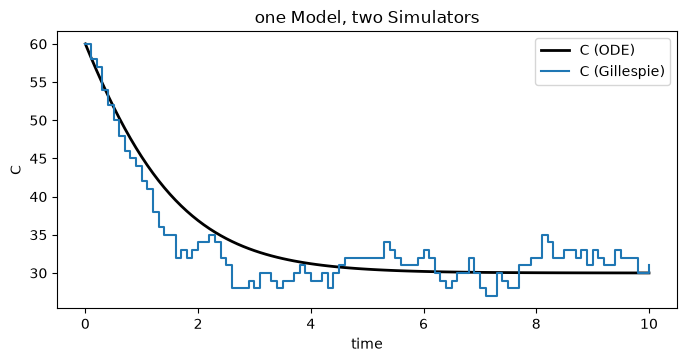

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4.prelude import *

# Real3 ベクトル演算
pos1 = Real3(1, 2, 3)
print('components:', pos1[0], pos1[1], pos1[2], '| length:', round(length(pos1), 3), '| dot:', dot_product(pos1, Real3(1,0,1)))

with reaction_rules():
    A + B > C | 0.01
    C > A + B | 0.3
m = get_model()

fig, ax = plt.subplots(figsize=(8,3.6))
# 同じ Model を ODE と Gillespie の World/Simulator で回す
for World, Simulator, lab, style in [(ode.World, ode.Simulator, 'ODE', '-'), (gillespie.World, gillespie.Simulator, 'Gillespie', 'steps')]:
    w = World(Real3(1,1,1)); w.bind_to(m); w.add_molecules(Species('C'), 60)
    sim = Simulator(w, m)
    obs = FixedIntervalNumberObserver(0.1, ('A', 'C'))
    sim.run(10.0, obs)
    d = np.array(obs.data())
    if style == '-': ax.plot(d[:,0], d[:,2], 'k-', lw=2, label=f'C ({lab})')
    else: ax.step(d[:,0], d[:,2], where='post', label=f'C ({lab})')
ax.set_xlabel('time'); ax.set_ylabel('C'); ax.legend(); ax.set_title('one Model, two Simulators'); plt.show()

**要点**: Model（反応の定義）と World/Simulator（状態と計算）が分離しているので、モデルを 1 度書けば
ソルバを差し替えて何度でも回せる。`Real3` は `length`/`dot_product` 等のベクトル演算を持ち、空間シミュレーションで使う。
`save_world('x.h5')` / `load_world('x.h5')` で状態を保存・再開できる。